# 01 - Exploratory data analysis and preprocessing

**Project:** AI scam & phishing message detector.

This notebook explains what is in the data, what the preprocessing did to it, and which
risks that creates for modelling. Charts are saved to `docs/figures/`.

**Run order** (from the repository root):

```
python -m src.preprocessing.combine        # Phase 1: merge sources -> combined.parquet
python -m src.preprocessing.preprocess     # Phase 2: clean, mask, dedup, split
jupyter nbconvert --execute ...            # or "Run all" in this notebook
```

**Hygiene:** everything that inspects message *content* (top words, lengths, masking
examples) uses the **train** split only, so the test set is never studied while designing
features. Counts-only overviews use the full deduplicated set.

In [1]:
import json
import os
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image, display

from src.preprocessing import eda
from src.preprocessing import preprocess as pp

pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 110)
PROC = ROOT / "data" / "processed"
FIG = ROOT / "docs" / "figures"

needed = ["combined", "deduplicated", "train", "val", "test"]
missing = [n for n in needed if not (PROC / f"{n}.parquet").exists()]
if missing:
    raise FileNotFoundError(f"Missing {missing}. Run the combine and preprocess commands first (see above).")

combined = pd.read_parquet(PROC / "combined.parquet")
dedup = pd.read_parquet(PROC / "deduplicated.parquet")
train, val, test = (pd.read_parquet(PROC / f"{n}.parquet") for n in ("train", "val", "test"))
report = json.loads((PROC / "split_report.json").read_text(encoding="utf-8"))
print(f"combined (Phase 1): {len(combined):,} rows | after preprocessing: {len(dedup):,} | "
      f"train/val/test: {len(train):,} / {len(val):,} / {len(test):,}")

combined (Phase 1): 24,541 rows | after preprocessing: 22,826 | train/val/test: 15,978 / 3,421 / 3,418


## 1. Class balance

Counts only, on the full deduplicated set.

,rows,share
label,,
safe,15646,0.685446
scam,7180,0.314554


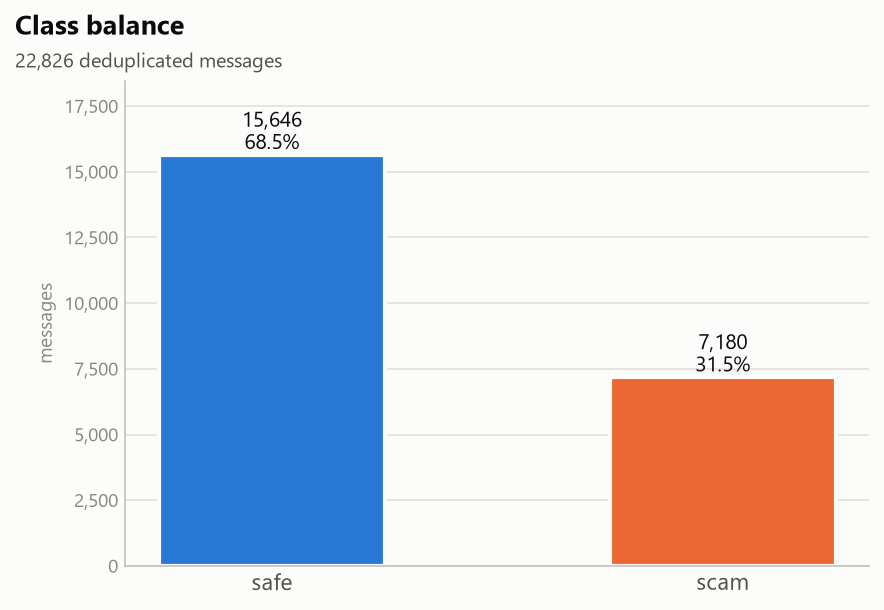

In [2]:
display(eda.class_counts(dedup))
display(Image(filename=str(eda.plot_class_balance(dedup, FIG / "class_balance.png"))))

## 2. Source confound: does the source leak the label?

The classes come from different corpora that differ in scam rate *and* in style (SMS vs old
email vs LLM-written text). If the source predicts the label, a model can score well without
learning anything about scams. Two checks: the scam rate per source, and **shortcut baselines** that predict the label from
the source and/or the message length alone (fit on train, scored on validation).

,rows,scam_rows,synthetic_share,scam_rate
source,,,,
hf_phishing_texts,11138,4048,0%,36.3%
uci_sms_spam,3478,377,0%,10.8%
synthetic_llm,1362,633,100%,46.5%


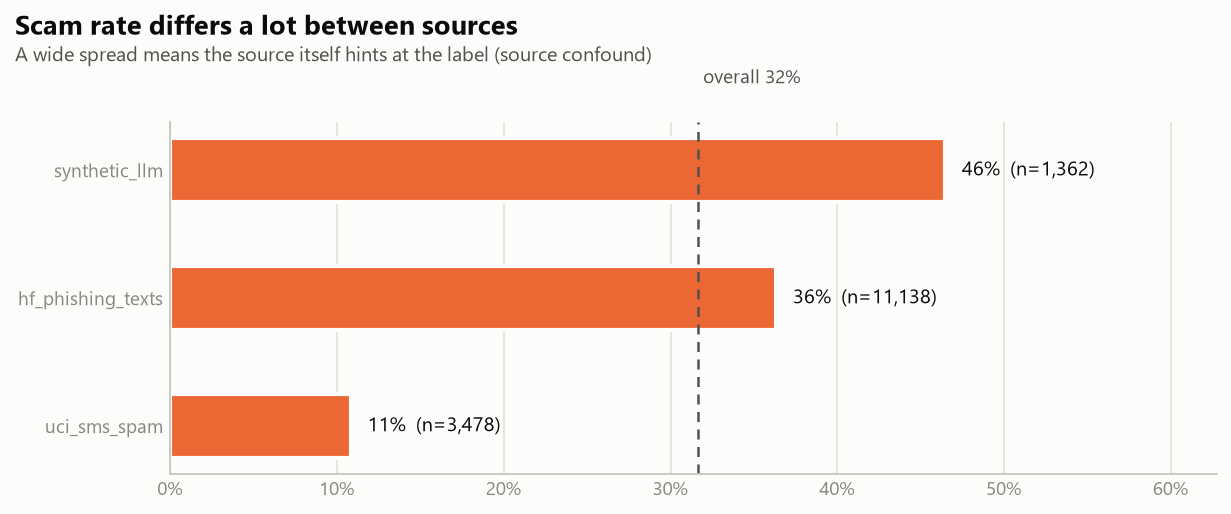

always predict 'safe': validation accuracy 0.684  (a majority-vote-by-source predictor scores the same: every source is majority-safe)

Validation ROC AUC of shortcut-only models (no message words used; 0.5 = chance):
  source only      0.619
  length only      0.557
  source + length  0.650


In [3]:
rates = eda.scam_rate_by_source(train)
display(rates.style.format({"synthetic_share": "{:.0%}", "scam_rate": "{:.1%}"}))
display(Image(filename=str(eda.plot_scam_rate_by_source(train, FIG / "scam_rate_by_source.png"))))

# Shortcut baselines: how well can the label be predicted WITHOUT reading the words?
# Majority-vote accuracy cannot show a confound here (every source is majority-safe, so
# it equals "always safe"), so we score probability estimates with ROC AUC (0.5 = chance).
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

sources = sorted(train["source"].unique())
y_train, y_val = (train["label"] == "scam").astype(int), (val["label"] == "scam").astype(int)


def shortcut_features(df, use_source, use_length):
    parts = []
    if use_source:
        parts.append(pd.get_dummies(df["source"]).reindex(columns=sources, fill_value=0).astype(float).to_numpy())
    if use_length:
        parts.append(np.log10(eda.text_lengths(df).clip(lower=1)).to_numpy()[:, None])
    return np.hstack(parts)


shortcut_auc = {}
for name, (use_source, use_length) in {"source only": (True, False), "length only": (False, True),
                                        "source + length": (True, True)}.items():
    model = LogisticRegression(max_iter=1000).fit(shortcut_features(train, use_source, use_length), y_train)
    proba = model.predict_proba(shortcut_features(val, use_source, use_length))[:, 1]
    shortcut_auc[name] = float(roc_auc_score(y_val, proba))

majority_label = train["label"].value_counts().idxmax()
majority_acc = float((val["label"] == majority_label).mean())
print(f"always predict '{majority_label}': validation accuracy {majority_acc:.3f}  "
      "(a majority-vote-by-source predictor scores the same: every source is majority-safe)")
print("\nValidation ROC AUC of shortcut-only models (no message words used; 0.5 = chance):")
for name, auc in shortcut_auc.items():
    print(f"  {name:<16} {auc:.3f}")

**Reading this:** an AUC well above 0.5 from *source* or *length* alone means a model can
partly "steal" the label from where a message came from or how long it is, without reading
its words. A real classifier must clearly beat these shortcut baselines to count as having
learned scam content. Phase 3 therefore reports **per-source results** and a
**leave-one-source-out** evaluation.

## 3. Message length

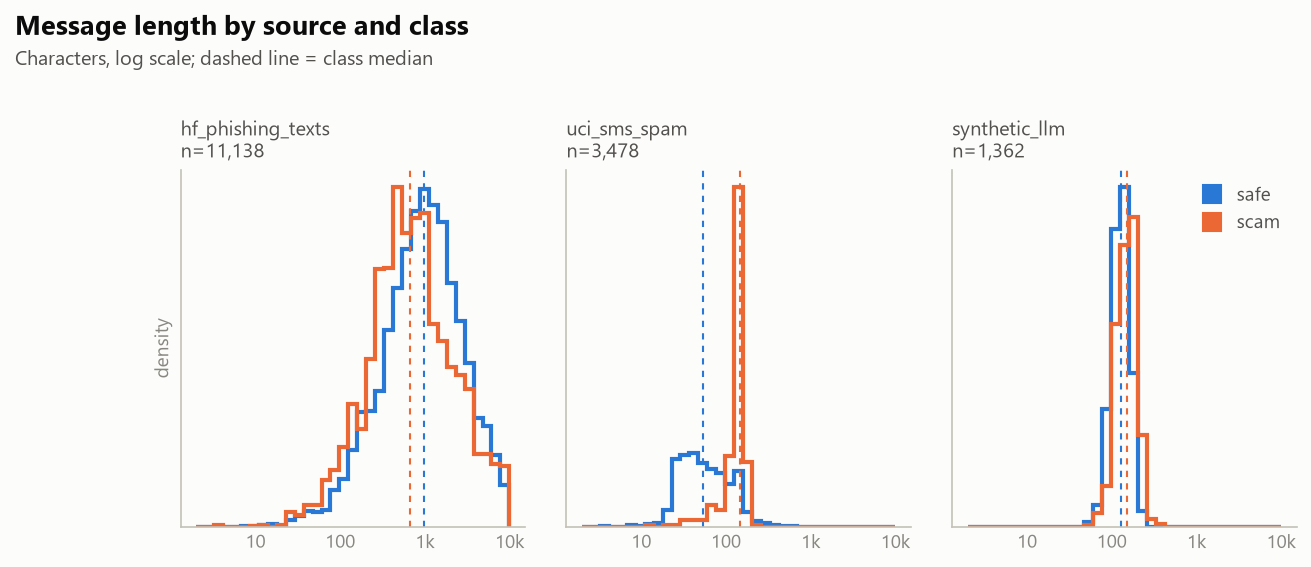

rows  median    mean     p95   max
source            label                                    
hf_phishing_texts safe   7090   979.5  1529.0  5185.5  9936
                  scam   4048   663.0  1295.3  5176.6  9980
synthetic_llm     safe    729   129.0   130.0   182.2   231
                  scam    633   152.0   154.0   226.0   422
uci_sms_spam      safe   3101    53.0    71.4   159.0   910
                  scam    377   148.0   135.6   162.2   223

In [4]:
display(Image(filename=str(eda.plot_length_distribution(train, FIG / "length_distribution.png"))))
display(eda.length_stats(train))

## 4. Language distribution

Language tags for real data come from a Unicode-script heuristic plus a small romanized-Hindi
word list (`hinglish_guess`), so real Hinglish is under-detected. Synthetic rows carry the
language they were generated in. See `src/preprocessing/language.py` for the limits.

label,safe,scam,total
language,,,
en,10319,4515,14834
hinglish,310,246,556
hi,73,64,137
bn_en,63,60,123
mr_en,50,59,109
te_en,54,53,107
ta_en,50,50,100
other,0,10,10
hinglish_guess,1,1,2


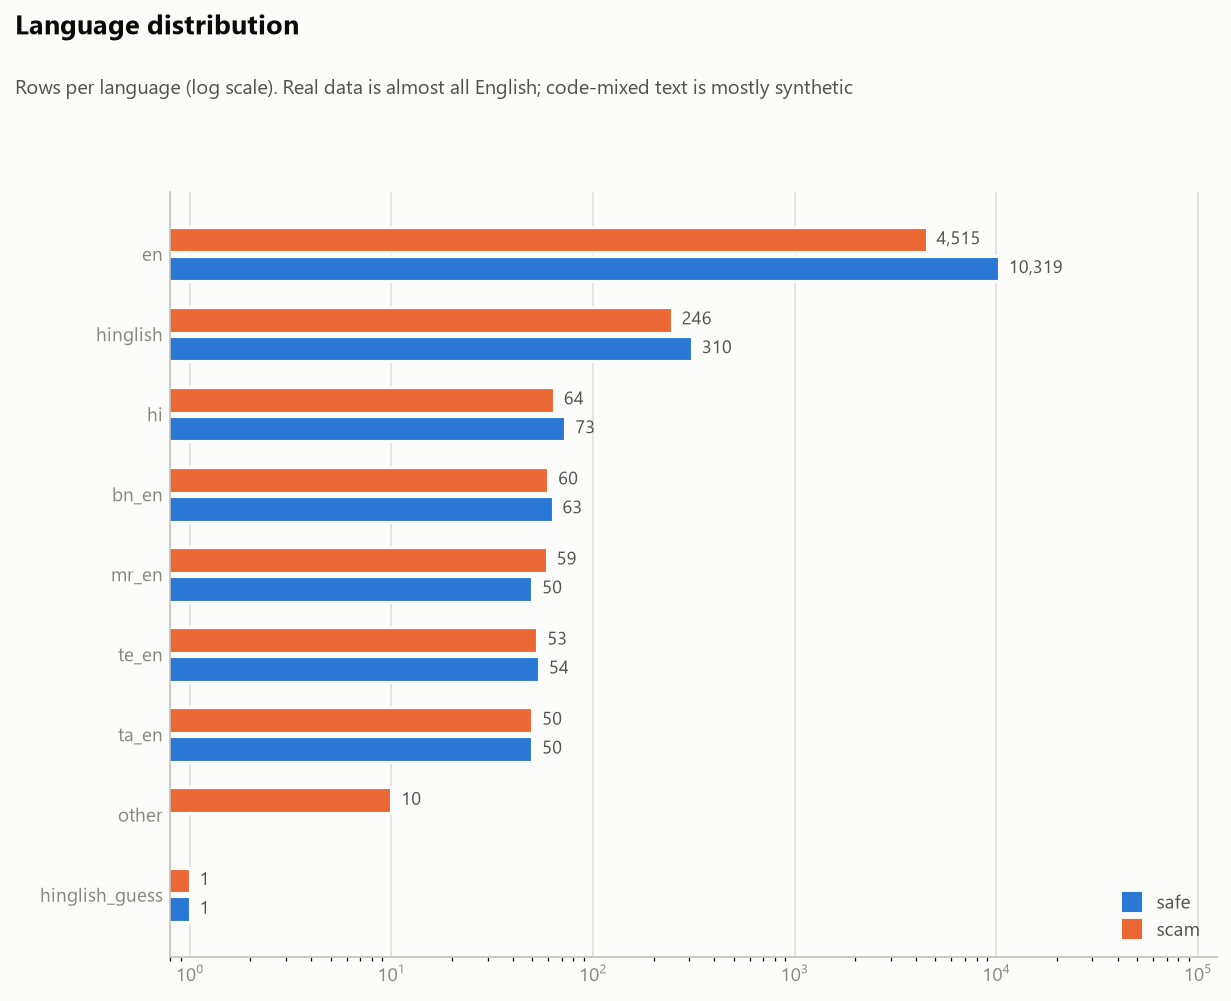

real training rows tagged Hindi/Hinglish: 0.01%


In [5]:
display(eda.language_counts(train))
display(Image(filename=str(eda.plot_language_distribution(train, FIG / "language_distribution.png"))))
real_train = train[~train["is_synthetic"]]
share_cm = real_train["language"].isin(["hinglish_guess", "hi"]).mean()
print(f"real training rows tagged Hindi/Hinglish: {share_cm:.2%}")

## 5. Most class-distinctive words (train)

Smoothed log-odds of document frequency: words that *separate* the classes, not merely common
ones. Masked tokens (`url`, `phone`, `otp`) are kept because "has a link / phone number / OTP"
is itself informative. Checked per source below to see which words are real scam vocabulary
and which are source style.

**What to expect:** the all-data chart is dominated by *corpus artifacts*, not scam vocabulary:
the "safe" side is Enron business email and a linguistics mailing list (`enron`, `kaminski`,
`hpl`, `linguist`), and the "scam" side is old pharma spam (`cialis`, `xanax`) including
deliberately misspelled words (`wiil`, `piease`, `oniine`). A model trained on this alone
would learn "1990s-2000s English email", not "Indian SMS scam". The short-message chart is
closer to the target use case.

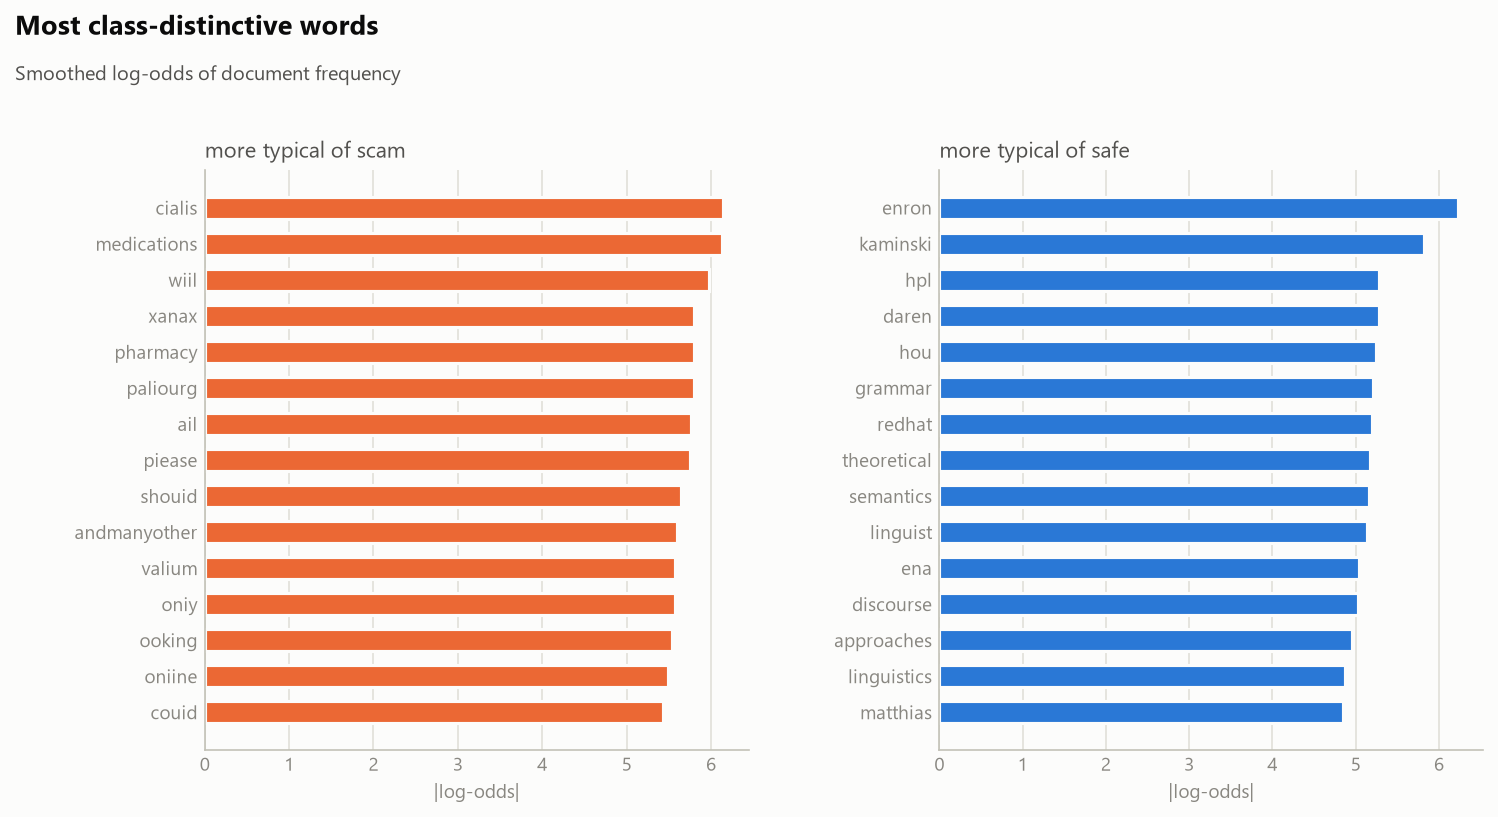

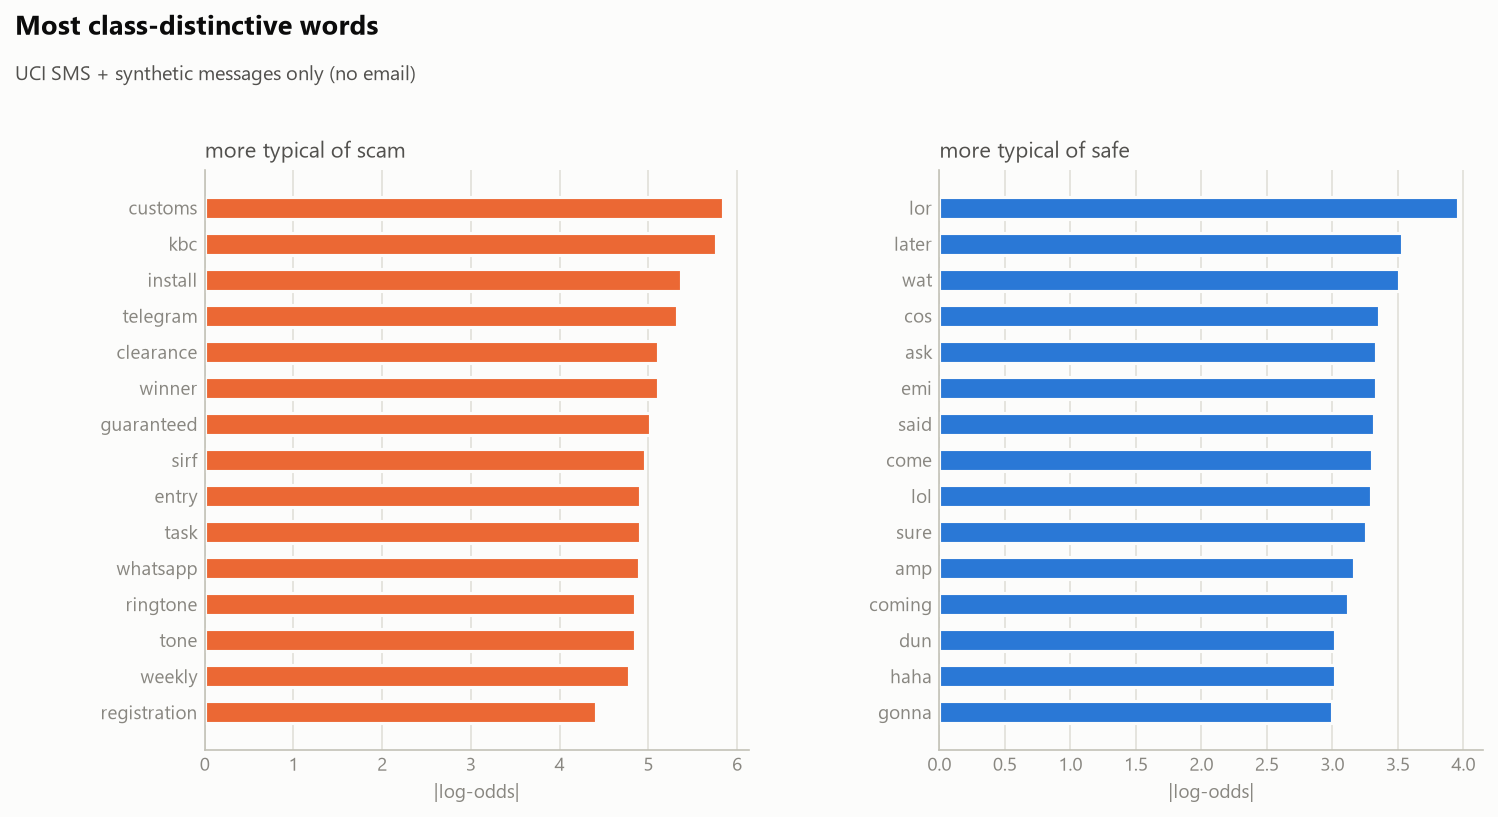


uci_sms_spam  (n=3,478)
  scam: claim, prize, ringtone, tone, guaranteed, tones, awarded, weekly, opt, unsubscribe
  safe: lor, later, wat, doing, cos, ask, said, come, lol, sure



hf_phishing_texts  (n=11,138)
  scam: meds, cialis, medications, wiil, pharmacy, paliourg, xanax, ail, piease, shouid
  safe: enron, kaminski, hpl, daren, hou, grammar, redhat, theoretical, semantics, linguist

synthetic_llm  (n=1,362)
  scam: customs, kbc, registration, earn, officer, telegram, install, clearance, like, sim
  safe: emi, sep, successful, interview, late, track, shopping, letter, scheduled, branch

Share of messages containing masked tokens, by label:


,,,
label,,,
safe,22.4%,2.6%,0.7%
scam,14.4%,10.3%,1.3%


In [6]:
words_all = eda.top_words_by_class(train, n=15, min_df=20)
display(Image(filename=str(eda.plot_top_words(words_all, FIG / "top_words.png"))))

# The all-data view is dominated by old email; repeat it for short messages only (SMS + synthetic).
short = train[train["source"] != "hf_phishing_texts"]
words_short = eda.top_words_by_class(short, n=15, min_df=15)
display(Image(filename=str(eda.plot_top_words(
    words_short, FIG / "top_words_short_messages.png",
    subtitle="UCI SMS + synthetic messages only (no email)"))))

for source in ["uci_sms_spam", "hf_phishing_texts", "synthetic_llm"]:
    part = train[train["source"] == source]
    if part["label"].nunique() < 2:
        continue
    w = eda.top_words_by_class(part, n=10, min_df=max(5, len(part) // 500))
    print(f"\n{source}  (n={len(part):,})")
    print("  scam:", ", ".join(w["scam"]["word"]))
    print("  safe:", ", ".join(w["safe"]["word"]))

print("\nShare of messages containing masked tokens, by label:")
display(eda.masked_token_rates(train).style.format("{:.1%}"))

## 6. Real vs synthetic

The test set must be 100% real. Synthetic rows (LLM-generated Hinglish and regional
code-mixed text) exist only in train and validation. The generator table checks that no single
LLM writes mostly one class, which would make "written by model X" a shortcut for the label.

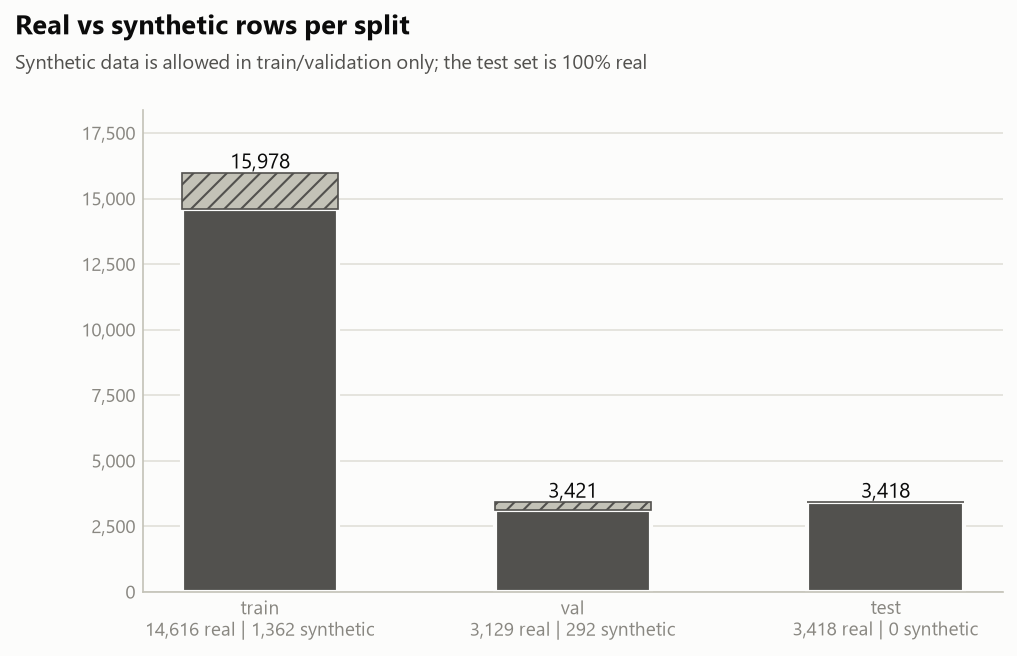

Synthetic training rows by generating model and label:


label,safe,scam,scam_share
generator,,,
gemini/gemini-3.5-flash-lite,374,360,0.490
gemini/gemini-3.7-flash,6,6,0.500
groq/openai/gpt-oss-120b,349,267,0.433


Synthetic rows by language and label:


label,safe,scam
language,,
bn_en,63,60
en,129,101
hi,73,64
hinglish,310,246
mr_en,50,59
ta_en,50,50
te_en,54,53


In [7]:
display(Image(filename=str(eda.plot_real_vs_synthetic({"train": train, "val": val, "test": test},
                                                      FIG / "real_vs_synthetic.png"))))
assert not test["is_synthetic"].any(), "the test set must contain no synthetic rows"
synth = train[train["is_synthetic"]]
gen = pd.crosstab(synth["generator"], synth["label"])
gen["scam_share"] = (gen["scam"] / gen.sum(axis=1)).round(3)
print("Synthetic training rows by generating model and label:")
display(gen)
print("Synthetic rows by language and label:")
display(pd.crosstab(synth["language"], synth["label"]))

## 7. Preprocessing: masking

URLs become `<URL>` (originals kept in the `urls` column for the URL analyzer), OTPs next to an
OTP keyword become `<OTP>`, and phone numbers become `<PHONE>`. Deduplication is run on the
*masked* text so templates that differ only by number or link collapse to one row.

In [8]:
changed = train[train["text"] != train["text_raw"]]
sample = pd.concat([changed[changed["source"] == s].sample(2, random_state=7)
                    for s in changed["source"].unique() if (changed["source"] == s).sum() >= 2])
for _, r in sample.iterrows():
    print(f"[{r['source']}]")
    print("  raw   :", r["text_raw"][:170].replace("\n", " "))
    print("  masked:", r["text"][:170])
    print("  urls  :", list(r["urls"])[:3], "\n")

[hf_phishing_texts]
  raw   : You around? C--  "I don't take no stocks in mathematics, anyway" --Huckleberry Finn
  masked: You around? C-- "I don't take no stocks in mathematics, anyway" --Huckleberry Finn
  urls  : [] 

[hf_phishing_texts]
  raw   : do u think that any girl will propose u today by seing ur bloody funky  face..........................
  masked: do u think that any girl will propose u today by seing ur bloody funky face..........................
  urls  : [] 

[synthetic_llm]
  raw   : Aapka referral code: REF839274. Join abhi, ₹20,000 daily earning guarantee. Pay ₹1,100 registration fee to 7623458910. Contact on Telegram @jobhunter
  masked: Aapka referral code: REF839274. Join abhi, ₹20,000 daily earning guarantee. Pay ₹1,100 registration fee to <PHONE>. Contact on Telegram @jobhunter
  urls  : [] 

[synthetic_llm]
  raw   : Hi friend, meeru part time work cheyali anukuntunara? Simple tasks vuntayi, like YouTube channel subscribe and video likes. Instant withdrawal u

## 8. Preprocessing: deduplication

Deduplicating *before* splitting stops near-identical messages landing on both sides of the
split, which would inflate test scores. Method: exact match on the normalized masked text, then
TF-IDF cosine similarity (word 1-2-grams, digits collapsed) at a threshold of 0.90, one row kept
per cluster (real rows preferred over synthetic).

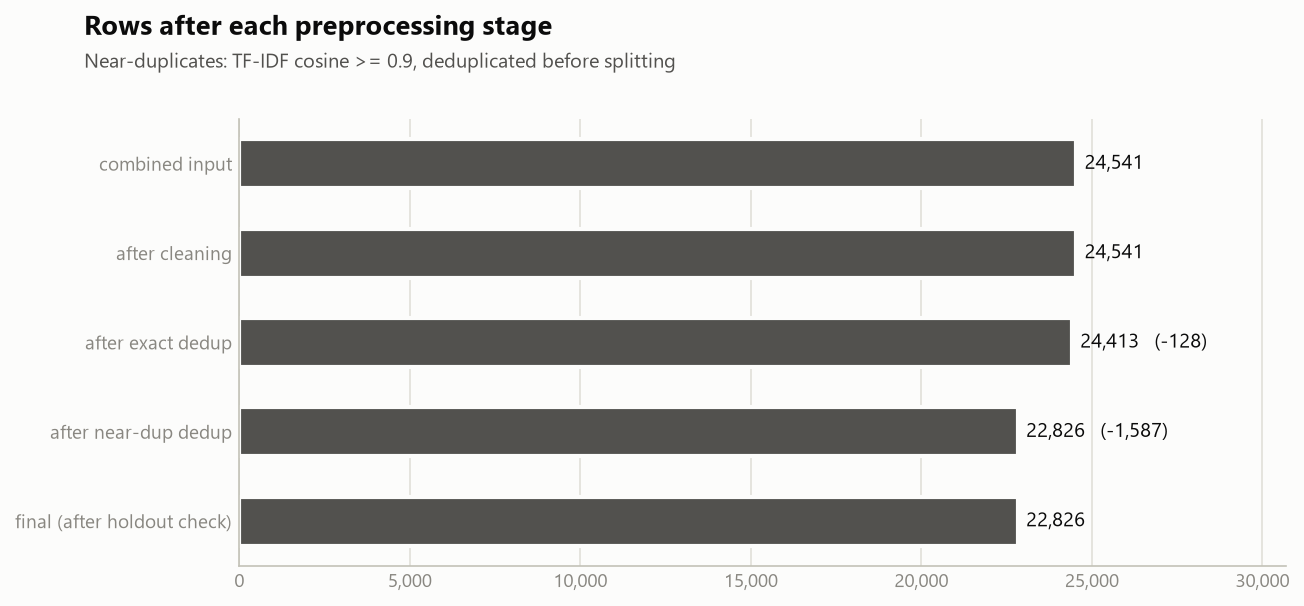

exact duplicates removed:      128   (+0 rows with conflicting labels)
near-duplicates removed:       1,587   (1,587 real, 0 synthetic)
near-duplicate clusters:       863   largest cluster: 137 rows
rows removed for overlap with the real-Indian holdout: 0
TOTAL removed by deduplication and cleaning: 1,715 of 24,541 (7.0%)

Threshold sensitivity (near-duplicate rows removed at each cosine cutoff):
  0.8: 2,676
  0.9: 1,587
  0.95: 994


In [9]:
display(Image(filename=str(eda.plot_dedup_funnel(report, FIG / "dedup_funnel.png"))))
ex, nd = report["exact_duplicates"], report["near_duplicates"]
print(f"exact duplicates removed:      {ex['removed']:,}   (+{ex['conflict_rows']:,} rows with conflicting labels)")
print(f"near-duplicates removed:       {nd['removed']:,}   ({nd['removed_real']:,} real, {nd['removed_synthetic']:,} synthetic)")
print(f"near-duplicate clusters:       {nd['clusters']:,}   largest cluster: {nd['max_cluster']:,} rows")
print(f"rows removed for overlap with the real-Indian holdout: {report.get('holdout_overlap_removed', 0):,}")
total_removed = report["input_rows"] - report["rows_after_dedup"]
print(f"TOTAL removed by deduplication and cleaning: {total_removed:,} of {report['input_rows']:,} "
      f"({total_removed / report['input_rows']:.1%})")
print("\nThreshold sensitivity (near-duplicate rows removed at each cosine cutoff):")
for th, n in report["near_duplicate_sensitivity"].items():
    print(f"  {th}: {n:,}")

## 9. Splits and leakage audit

Stratified 70/15/15 by label and source. The test set is drawn from real data only. After the
split, any validation/test row that is still similar to a row in another split is trimmed, and
the audit re-measures cross-split similarity.

In [10]:
rows = []
for name, part in (("train", train), ("val", val), ("test", test)):
    rows.append({"split": name, "rows": len(part), "share": len(part) / (len(train) + len(val) + len(test)),
                 "safe": int((part["label"] == "safe").sum()), "scam": int((part["label"] == "scam").sum()),
                 "scam_rate": (part["label"] == "scam").mean(), "synthetic": int(part["is_synthetic"].sum())})
display(pd.DataFrame(rows).set_index("split").style.format({"share": "{:.1%}", "scam_rate": "{:.1%}"}))
print("borderline rows trimmed after the split:", report["leakage_trimmed"])
display(pd.DataFrame(report["leakage_audit"]).T)
pp.check_split_integrity(train, val, test)     # raises if any id/text overlaps or synthetic is in test
print("integrity checks passed: no id or exact-text overlap between splits, test set is 100% real")

,rows,share,safe,scam,scam_rate,synthetic
split,,,,,,
train,15978,70.0%,10920,5058,31.7%,1362
val,3421,15.0%,2339,1082,31.6%,292
test,3418,15.0%,2386,1032,30.2%,0


borderline rows trimmed after the split: {'val': 3, 'test': 6}


,near_duplicate_rows,max_similarity
val_vs_train,0.0,0.9000
test_vs_train,0.0,0.8998
test_vs_val,0.0,0.8981


integrity checks passed: no id or exact-text overlap between splits, test set is 100% real


## 10. Hand-collected real Indian test set (optional)

Real English corpora hold almost no Hinglish, so the headline test set cannot measure it. A
small set of real Indian messages, labelled by hand (see `docs/labeling_guidelines.md`), fills
that gap. It is evaluation-only and never used for training.

In [11]:
holdout_path = PROC / "real_indian_test.parquet"
if holdout_path.exists():
    holdout = pd.read_parquet(holdout_path)
    print(f"real_indian_test: {len(holdout):,} rows")
    display(pd.crosstab(holdout["language"], holdout["label"]))
    pp.check_split_integrity  # (holdout disjointness is enforced when it is built)
else:
    print("real_indian_test.parquet not built yet. Fill in docs/real_indian_test_template.csv and run:")
    print("  python -m src.preprocessing.real_indian_test data/real_indian/messages.csv")

real_indian_test.parquet not built yet. Fill in docs/real_indian_test_template.csv and run:
  python -m src.preprocessing.real_indian_test data/real_indian/messages.csv


## 11. Findings and what they mean for modelling

In [12]:
real_test = test
print("KEY NUMBERS")
print(f"- Class balance (all data): {(dedup['label'] == 'scam').mean():.1%} scam.")
print("- Shortcut-only validation ROC AUC (no words used): "
      + ", ".join(f"{k} {v:.3f}" for k, v in shortcut_auc.items()) + ".")
print(f"- Synthetic rows: {int(dedup['is_synthetic'].sum()):,} of {len(dedup):,} "
      f"({dedup['is_synthetic'].mean():.1%}); in the test set: {int(test['is_synthetic'].sum())}.")
print(f"- Real rows tagged Hindi/Hinglish in train: {share_cm:.2%}.")
print(f"- Deduplication removed {total_removed:,} rows ({total_removed / report['input_rows']:.1%}); "
      f"{nd['removed']:,} were near-duplicates, largest cluster {nd['max_cluster']:,} rows.")

KEY NUMBERS
- Class balance (all data): 31.5% scam.
- Shortcut-only validation ROC AUC (no words used): source only 0.619, length only 0.557, source + length 0.650.
- Synthetic rows: 1,654 of 22,826 (7.2%); in the test set: 0.
- Real rows tagged Hindi/Hinglish in train: 0.01%.
- Deduplication removed 1,715 rows (7.0%); 1,587 were near-duplicates, largest cluster 137 rows.


**Implications for Phase 3 and beyond**

1. **Source confound.** The source predicts the label better than chance (section 2). Report
   metrics per source and with **leave-one-source-out** evaluation (train on all sources but
   one, test on the held-out one). If the score collapses on the held-out source, the model
   learned source style. Mitigations, in order: (a) evaluate per source and report the worst
   case, not the average; (b) re-weight so each source contributes equal weight per class;
   (c) balance scam rate within each source by sub-sampling; (d) strip source-specific
   artifacts (email headers, very long bodies) and re-check.
2. **The test set is almost entirely English.** Headline test metrics say little about
   Hinglish. Synthetic-validation scores are *diagnostic only*; the real-Indian holdout is the
   only honest Hinglish measure.
3. **Length differs strongly by source** (SMS are short, emails long). Avoid using raw length
   as a feature, and consider truncating emails to the SMS-length range for fairness checks.
4. **Masked tokens carry signal** (e.g. share of messages with a URL). That is fine and
   intended, but it means the URL analyzer and classifier should be evaluated together.